# DINO-BoC 官方原始碼導讀
## 跟著一次真實 forward 資料流，讀懂 dinov2 怎麼實作 Bag-of-Channels

本筆記本是 `channel_adaptive_dino.ipynb`（toy 重實作，教**原理**）的姊妹篇，
專門教**官方 dinov2 怎麼寫** DINO-BoC。我們**讀真實原始碼**為主軸，並在**真實 import 的類別**上
跑極小 toy forward（<10 張合成圖）看 shape 變化。

**讀法**：跟著一次真實的特徵抽取資料流走 —
③ 資料層（通道被拆獨立）→ ④ config/hub（模型怎麼被建出來）→ ① ViT reshape（主幹）→ ② linear concat（融合）。

**環境前提**
- 以 `sys.path` 引入使用者 fork：`/Users/adamw/work/dinov2`（不安裝、不下載權重）。
- 缺 xFormers 會自動 fallback 到 native attention（只有 warning，可正常跑）。
- toy forward 用 `vit_small`（D=384）**代跑**真實 ViT-L/16（D=1024）：reshape 機制一模一樣，只有 D 數字不同。

In [1]:
import sys, warnings
sys.path.insert(0, "/Users/adamw/work/dinov2")            # 引入官方 dinov2 fork（不安裝、不動環境）
warnings.filterwarnings("ignore", message=".*xFormers.*")  # 只壓 xFormers 缺失警告，保留 glyph 警告可見
import torch, numpy as np
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["PingFang HK", "Arial Unicode MS"]
matplotlib.rcParams["axes.unicode_minus"] = False
print("torch", torch.__version__, "| MPS", torch.backends.mps.is_available())

torch 2.10.0 | MPS True


## §1 鳥瞰：一次真實特徵抽取的資料流

下圖把四塊原始碼依**資料流**串起來。後面每一節各放大一塊。

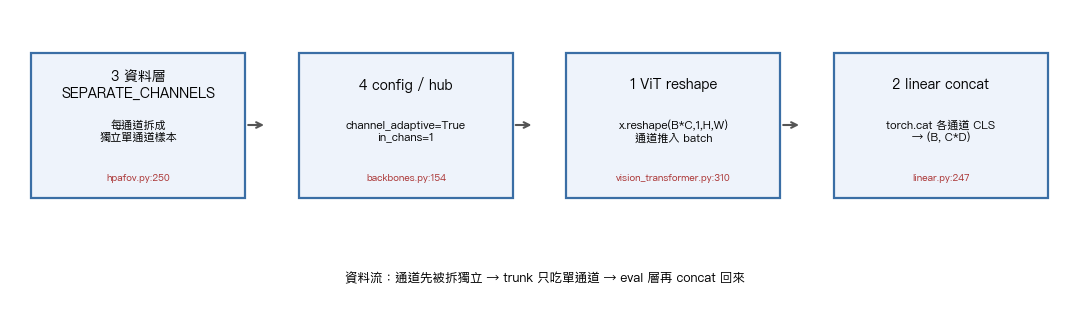

In [2]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 3.2)); ax.axis("off")
stages = [
    ("3 資料層\nSEPARATE_CHANNELS", "hpafov.py:250", "每通道拆成\n獨立單通道樣本"),
    ("4 config / hub", "backbones.py:154", "channel_adaptive=True\nin_chans=1"),
    ("1 ViT reshape", "vision_transformer.py:310", "x.reshape(B*C,1,H,W)\n通道推入 batch"),
    ("2 linear concat", "linear.py:247", "torch.cat 各通道 CLS\n→ (B, C*D)"),
]
n = len(stages)
for i,(title,loc,desc) in enumerate(stages):
    x = i/(n) + 0.02
    ax.add_patch(plt.Rectangle((x,0.35),0.20,0.5, fill=True, facecolor="#eef3fb",
                               edgecolor="#3a6ea5", lw=1.6, transform=ax.transAxes))
    ax.text(x+0.10,0.74,title,ha="center",va="center",fontsize=10,weight="bold",transform=ax.transAxes)
    ax.text(x+0.10,0.58,desc,ha="center",va="center",fontsize=8,transform=ax.transAxes)
    ax.text(x+0.10,0.42,loc,ha="center",va="center",fontsize=7,color="#a33",transform=ax.transAxes)
    if i<n-1:
        ax.annotate("",(x+0.22,0.6),(x+0.20,0.6),xycoords="axes fraction",
                    arrowprops=dict(arrowstyle="->",lw=1.5,color="#555"))
ax.text(0.5,0.06,"資料流：通道先被拆獨立 → trunk 只吃單通道 → eval 層再 concat 回來",
        ha="center",fontsize=9,style="italic",transform=ax.transAxes)
plt.tight_layout(); plt.show()

## §2 資料層：`SEPARATE_CHANNELS`（channel-agnostic 的源頭）

BoC 的「通道無關」不是模型決定的，是**資料層**決定的：預訓練時每個通道被當成一張**獨立的單通道樣本**，
backbone 一次只看一個通道，所以它根本沒機會學「跨通道」的東西。

**`dinov2/data/datasets/cell_dino/hpafov.py:107`**

```python
SEPARATECHANNELS = "separate_channels"  # each channel from each image
# is treated as an independent sample, overrides chosen channel configuration
```

**`dinov2/data/datasets/cell_dino/hpafov.py:250-258`**

```python
# 原本每張影像有 4 個通道索引：shape (num_images, 4)
self._channels = np.repeat(np.array([[0, 1, 2, 3]]), len(self._image_paths), axis=0).tolist()
...
if self.wildcard == _WildCard.SEPARATECHANNELS.value.upper():
    C = channels.shape[1]
    # 把通道維「攤平」進樣本維：4 通道 x N 張 → 4N 個單通道樣本
    channels = np.concatenate([channels[:, i] for i in range(C)])
    self._channels = np.expand_dims(channels, 1).tolist()
```

用一個迷你 numpy demo 看這個「攤平」到底做了什麼（拿 3 張 4 通道影像示意）：

In [3]:
N, C = 3, 4
channels = np.repeat(np.array([[0,1,2,3]]), N, axis=0)
print("拆之前 channels.shape :", channels.shape, "  (N 張, 每張 4 通道)")
flat = np.concatenate([channels[:, i] for i in range(C)])
sep = np.expand_dims(flat, 1)
print("拆之後 sep.shape      :", sep.shape, "  (4N 個獨立單通道樣本)")
print("每個樣本只帶 1 個通道索引：", sep[:,0].tolist())

拆之前 channels.shape : (3, 4)   (N 張, 每張 4 通道)
拆之後 sep.shape      : (12, 1)   (4N 個獨立單通道樣本)
每個樣本只帶 1 個通道索引： [0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3]


> 結論：trunk 之所以是**純單通道**(`in_chans=1`)，是因為資料層在更上游就保證了「一次只餵一個通道」。
> 這條設計把後面 §4/§5 的 late-fusion **逼了出來**——融合只能放在後面做。

## §3 模型怎麼被建出來：config → hub → `self.bag_of_channels`

BoC **不需要新模型**：就是一個標準 DINOv2 ViT，差別只在兩個旗標 `channel_adaptive: true` 與 `in_chans: 1`。
它們從 train config / hub entrypoint 一路傳到 `DinoVisionTransformer.__init__`。

**`dinov2/configs/train/cell_dino/vitl16_boc_hpafov.yaml:4-9`**

```python
train:
  channel_adaptive: true        # 開啟 BoC
student:
  arch: vit_large
  patch_size: 16
  in_chans: 1   # 單通道 backbone
```

**`dinov2/hub/cell_dino/backbones.py:154-180`**

```python
def channel_adaptive_dino_vitl16(
    ...
    channel_adaptive: bool = True,
):
    ...
    return _make_cell_dino_model(
        ..., in_chans=in_channels, channel_adaptive=channel_adaptive)
```

**`dinov2/models/vision_transformer.py:107`**

```python
self.bag_of_channels = channel_adaptive   # 旗標落地：之後所有 reshape 都看它
```

我們在**真實類別**上把這條鏈走一遍（用 vit_small 代跑 ViT-L，旗標行為一致）：

In [4]:
from dinov2.models.vision_transformer import vit_small
model = vit_small(patch_size=16, in_chans=1, channel_adaptive=True, img_size=224).eval()
print("型別           :", type(model).__name__)
print("in_chans (patch):", model.patch_embed.proj.in_channels, " <- 單通道")
print("bag_of_channels :", model.bag_of_channels, "        <- BoC 開啟")

型別           : DinoVisionTransformer
in_chans (patch): 1  <- 單通道
bag_of_channels : True         <- BoC 開啟


## §4 核心①：ViT reshape —— BoC 的靈魂只有兩行

BoC 不在主幹裡。融合縫在 `get_intermediate_layers` 的**進出口各一行 reshape**：
進口把通道推進 batch 維（讓單通道 backbone 逐通道各跑一次），出口再把 CLS 攤回 `(B, C*D)`。

**`dinov2/models/vision_transformer.py:310`**

```python
if self.bag_of_channels:\n    B, C, H, W = x.shape\n    x = x.reshape(B * C, 1, H, W)  # 進口：通道推入 batch，逐通道各跑一次單通道 ViT
```

**`dinov2/models/vision_transformer.py:329-345`**

```python
if self.bag_of_channels:\n    ...\n    # 出口：patch token 還原成 (B, C, N, D)、class token 攤平成 (B, C*D)\n    patch_tokens = [pt.reshape(B, C, pt.shape[-2], pt.shape[-1]) for pt in patch_tokens_per_block]\n    cls_tokens   = [ct.reshape(B, -1) for ct in cls_tokens_per_block]
```

**Live toy forward**（B=2 張、C=5 通道、224×224；vit_small 隨機初始化）。注意 cls 出來是 `(B, C*D)`：

In [5]:
x = torch.randn(2, 5, 224, 224)   # B=2 張，C=5 通道（<10 張，聚焦 shape）
with torch.no_grad():
    outs = model.get_intermediate_layers(x, n=1, return_class_token=True, reshape=False)
patch, cls = outs[0]
print("輸入            :", tuple(x.shape))
print("patch tokens    :", tuple(patch.shape), "  = (B, C, N, D)，N=196 個 patch")
print("class tokens    :", tuple(cls.shape),   "      = (B, C*D) = (2, 5*384)")
assert tuple(patch.shape) == (2, 5, 196, 384)
assert tuple(cls.shape) == (2, 1920)

輸入            : (2, 5, 224, 224)
patch tokens    : (2, 5, 196, 384)   = (B, C, N, D)，N=196 個 patch
class tokens    : (2, 1920)       = (B, C*D) = (2, 5*384)


**error 當教材**：直接餵 5 通道給 `forward_features`（訓練主幹入口）會炸——
因為 patch_embed 是 `in_chans=1`。這正證明 trunk 是**純單通道**、late-fusion 不在主幹裡：

In [6]:
try:
    model.forward_features(torch.randn(2, 5, 224, 224))
except RuntimeError as e:
    print("如預期報錯：", str(e).split(chr(10))[0])

如預期報錯： Given groups=1, weight of size [384, 1, 16, 16], expected input[2, 5, 224, 224] to have 1 channels, but got 5 channels instead
